In [1]:
# --------------------------------------------------
# K-NEAREST NEIGHBORS CLASSIFICATION PROJECT
# --------------------------------------------------

# Import pandas for working with data
import pandas as pd

# Import numpy for numerical work
import numpy as np

# Import matplotlib for charts
import matplotlib.pyplot as plt

# Import seaborn for visualization
import seaborn as sns

In [2]:
# --------------------------------------------------
# LOAD THE CKD DATASET
# --------------------------------------------------

# Read the chronic kidney disease dataset
ckd = pd.read_csv(
    r'D:\MiniForge\Ex_Files_Intro_to_Data_Science\Ex_Files_Intro_to_Data_Science\Exercise Files\ckd.csv'
)

# Display first 5 rows
ckd.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Blood Glucose Random,...,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
0,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
1,53,90,1.020,2,0,abnormal,abnormal,present,notpresent,70,...,29,12100,3.7,yes,yes,no,poor,no,yes,1
2,63,70,1.010,3,0,abnormal,abnormal,present,notpresent,380,...,32,4500,3.8,yes,yes,no,poor,yes,no,1
3,68,80,1.010,3,2,normal,abnormal,present,present,157,...,16,11000,2.6,yes,yes,yes,poor,yes,no,1
4,61,80,1.015,2,0,abnormal,abnormal,notpresent,notpresent,173,...,24,9200,3.2,yes,yes,yes,poor,yes,yes,1


In [3]:
# --------------------------------------------------
# CHECK DATASET INFORMATION
# --------------------------------------------------

# Display rows, columns, and data types
ckd.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      158 non-null    int64  
 1   Blood Pressure           158 non-null    int64  
 2   Specific Gravity         158 non-null    float64
 3   Albumin                  158 non-null    int64  
 4   Sugar                    158 non-null    int64  
 5   Red Blood Cells          158 non-null    str    
 6   Pus Cell                 158 non-null    str    
 7   Pus Cell clumps          158 non-null    str    
 8   Bacteria                 158 non-null    str    
 9   Blood Glucose Random     158 non-null    int64  
 10  Blood Urea               158 non-null    int64  
 11  Serum Creatinine         158 non-null    float64
 12  Sodium                   158 non-null    int64  
 13  Potassium                158 non-null    float64
 14  Hemoglobin               158 non-null

In [4]:
# --------------------------------------------------
# DISPLAY COLUMN NAMES
# --------------------------------------------------

# Show exact column names
ckd.columns

Index(['Age', 'Blood Pressure', 'Specific Gravity', 'Albumin', 'Sugar',
       'Red Blood Cells', 'Pus Cell', 'Pus Cell clumps', 'Bacteria',
       'Blood Glucose Random', 'Blood Urea', 'Serum Creatinine', 'Sodium',
       'Potassium', 'Hemoglobin', 'Packed Cell Volume',
       'White Blood Cell Count', 'Red Blood Cell Count', 'Hypertension',
       'Diabetes Mellitus', 'Coronary Artery Disease', 'Appetite',
       'Pedal Edema', 'Anemia', 'Class'],
      dtype='str')

In [5]:
# --------------------------------------------------
# CHECK FOR MISSING VALUES
# --------------------------------------------------

# Count missing values in each column
ckd.isna().sum()

Age                        0
Blood Pressure             0
Specific Gravity           0
Albumin                    0
Sugar                      0
Red Blood Cells            0
Pus Cell                   0
Pus Cell clumps            0
Bacteria                   0
Blood Glucose Random       0
Blood Urea                 0
Serum Creatinine           0
Sodium                     0
Potassium                  0
Hemoglobin                 0
Packed Cell Volume         0
White Blood Cell Count     0
Red Blood Cell Count       0
Hypertension               0
Diabetes Mellitus          0
Coronary Artery Disease    0
Appetite                   0
Pedal Edema                0
Anemia                     0
Class                      0
dtype: int64

In [6]:
# --------------------------------------------------
# REMOVE MISSING VALUES
# --------------------------------------------------

# Drop rows with missing values
ckd_clean = ckd.dropna()

# Display cleaned dataset shape
ckd_clean.shape

(158, 25)

In [7]:
# Display the exact column names
ckd_clean.columns.tolist()

['Age',
 'Blood Pressure',
 'Specific Gravity',
 'Albumin',
 'Sugar',
 'Red Blood Cells',
 'Pus Cell',
 'Pus Cell clumps',
 'Bacteria',
 'Blood Glucose Random',
 'Blood Urea',
 'Serum Creatinine',
 'Sodium',
 'Potassium',
 'Hemoglobin',
 'Packed Cell Volume',
 'White Blood Cell Count',
 'Red Blood Cell Count',
 'Hypertension',
 'Diabetes Mellitus',
 'Coronary Artery Disease',
 'Appetite',
 'Pedal Edema',
 'Anemia',
 'Class']

In [8]:
# --------------------------------------------------
# CHECK CLASS COLUMN VALUES
# --------------------------------------------------

# Count each class/category
ckd_clean['Class'].value_counts()

Class
0    115
1     43
Name: count, dtype: int64

In [9]:
# --------------------------------------------------
# SELECT ATTRIBUTES AND CLASS
# --------------------------------------------------

# Select the columns used to make predictions
X = ckd_clean.drop('Class', axis=1)

# Select the column we want to predict
y = ckd_clean['Class']

In [10]:
# --------------------------------------------------
# CONVERT CATEGORICAL DATA INTO NUMBERS
# --------------------------------------------------

# Convert text/category columns into numerical columns
X = pd.get_dummies(X)

In [13]:
# --------------------------------------------------
# SPLIT DATA INTO TRAINING AND TESTING SETS
# --------------------------------------------------

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
!pip install scikit-learn

In [15]:
# --------------------------------------------------
# SPLIT DATA INTO TRAINING AND TESTING SETS
# --------------------------------------------------

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# --------------------------------------------------
# CREATE THE K-NN CLASSIFIER
# --------------------------------------------------

# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

# Create a k-NN classifier with k = 5
knn = KNeighborsClassifier(
    n_neighbors=5
)

In [17]:
# --------------------------------------------------
# TRAIN THE CLASSIFIER
# --------------------------------------------------

# Train the model using the training data
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
# --------------------------------------------------
# MAKE PREDICTIONS
# --------------------------------------------------

# Predict classes for the test data
y_pred = knn.predict(X_test)

# Display predictions
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [19]:
# --------------------------------------------------
# CHECK MODEL ACCURACY
# --------------------------------------------------

# Import accuracy score
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
accuracy

0.8125

In [20]:
# --------------------------------------------------
# DISPLAY CONFUSION MATRIX
# --------------------------------------------------

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
cm

array([[23,  0],
       [ 6,  3]])

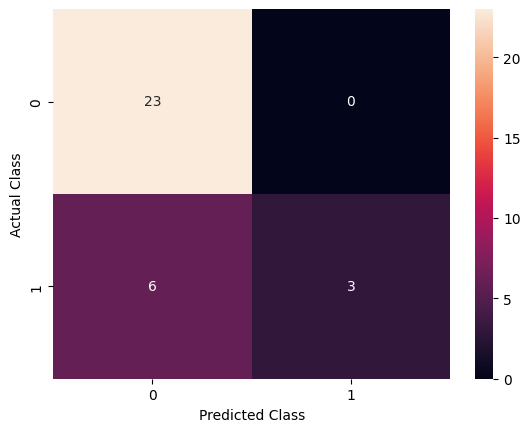

In [21]:
# --------------------------------------------------
# VISUALIZE CONFUSION MATRIX
# --------------------------------------------------

# Create heatmap of confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

# Add labels
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Display chart
plt.show()

In [22]:
# --------------------------------------------------
# DISPLAY CLASSIFICATION REPORT
# --------------------------------------------------

# Import classification report
from sklearn.metrics import classification_report

# Display precision, recall, and f1-score
print(
    classification_report(y_test, y_pred)
)

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        23
           1       1.00      0.33      0.50         9

    accuracy                           0.81        32
   macro avg       0.90      0.67      0.69        32
weighted avg       0.85      0.81      0.78        32



In [27]:
ckd_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      158 non-null    int64  
 1   Blood Pressure           158 non-null    int64  
 2   Specific Gravity         158 non-null    float64
 3   Albumin                  158 non-null    int64  
 4   Sugar                    158 non-null    int64  
 5   Red Blood Cells          158 non-null    str    
 6   Pus Cell                 158 non-null    str    
 7   Pus Cell clumps          158 non-null    str    
 8   Bacteria                 158 non-null    str    
 9   Blood Glucose Random     158 non-null    int64  
 10  Blood Urea               158 non-null    int64  
 11  Serum Creatinine         158 non-null    float64
 12  Sodium                   158 non-null    int64  
 13  Potassium                158 non-null    float64
 14  Hemoglobin               158 non-null

In [28]:
# Display class percentages
ckd_clean["Class"].value_counts(normalize=True)

Class
0    0.727848
1    0.272152
Name: proportion, dtype: float64

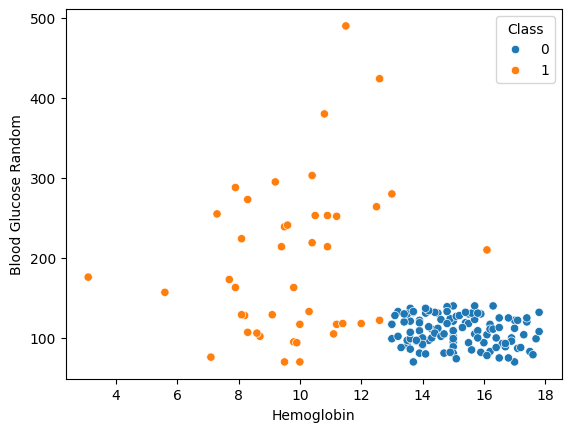

In [29]:
# Create scatterplot
sns.scatterplot(
    x="Hemoglobin",
    y="Blood Glucose Random",
    data=ckd_clean,
    hue="Class"
)

# Display chart
plt.show()

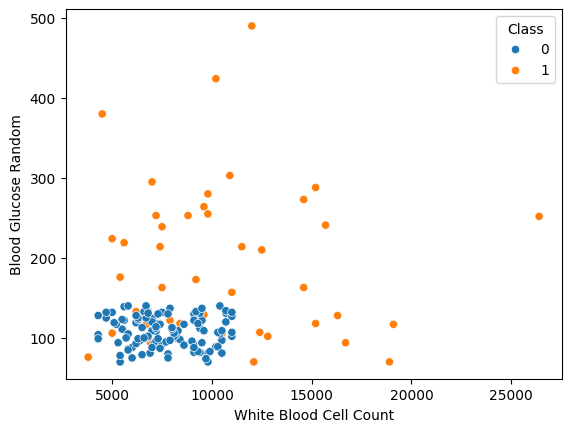

In [30]:
# Create scatterplot
sns.scatterplot(
    x="White Blood Cell Count",
    y="Blood Glucose Random",
    data=ckd_clean,
    hue="Class"
)

# Display chart
plt.show()

In [31]:
# Select feature columns
X = ckd_clean.drop(columns="Class")

# Display first 5 rows
X.head()

# Display dataframe information
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      158 non-null    int64  
 1   Blood Pressure           158 non-null    int64  
 2   Specific Gravity         158 non-null    float64
 3   Albumin                  158 non-null    int64  
 4   Sugar                    158 non-null    int64  
 5   Red Blood Cells          158 non-null    str    
 6   Pus Cell                 158 non-null    str    
 7   Pus Cell clumps          158 non-null    str    
 8   Bacteria                 158 non-null    str    
 9   Blood Glucose Random     158 non-null    int64  
 10  Blood Urea               158 non-null    int64  
 11  Serum Creatinine         158 non-null    float64
 12  Sodium                   158 non-null    int64  
 13  Potassium                158 non-null    float64
 14  Hemoglobin               158 non-null

In [32]:
ckd_clean

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Blood Glucose Random,...,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
0,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
1,53,90,1.020,2,0,abnormal,abnormal,present,notpresent,70,...,29,12100,3.7,yes,yes,no,poor,no,yes,1
2,63,70,1.010,3,0,abnormal,abnormal,present,notpresent,380,...,32,4500,3.8,yes,yes,no,poor,yes,no,1
3,68,80,1.010,3,2,normal,abnormal,present,present,157,...,16,11000,2.6,yes,yes,yes,poor,yes,no,1
4,61,80,1.015,2,0,abnormal,abnormal,notpresent,notpresent,173,...,24,9200,3.2,yes,yes,yes,poor,yes,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,55,80,1.020,0,0,normal,normal,notpresent,notpresent,140,...,47,6700,4.9,no,no,no,good,no,no,0
154,42,70,1.025,0,0,normal,normal,notpresent,notpresent,75,...,54,7800,6.2,no,no,no,good,no,no,0
155,12,80,1.020,0,0,normal,normal,notpresent,notpresent,100,...,49,6600,5.4,no,no,no,good,no,no,0
156,17,60,1.025,0,0,normal,normal,notpresent,notpresent,114,...,51,7200,5.9,no,no,no,good,no,no,0


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0
)

In [34]:
X_train.head()


,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Blood Glucose Random,...,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia
27,21,90,1.010,4,0,normal,abnormal,present,present,107,...,8.3,23,12400,3.9,no,no,no,good,no,yes
111,43,60,1.025,0,0,normal,normal,notpresent,notpresent,108,...,17.8,43,7200,5.5,no,no,no,good,no,no
110,22,60,1.025,0,0,normal,normal,notpresent,notpresent,97,...,13.5,42,7900,6.4,no,no,no,good,no,no
85,43,80,1.025,0,0,normal,normal,notpresent,notpresent,81,...,13.9,48,6900,4.9,no,no,no,good,no,no
18,52,90,1.015,4,3,normal,abnormal,notpresent,notpresent,224,...,8.1,23,5000,2.9,yes,yes,no,good,no,yes


In [35]:
y_train.head()

27     1
111    0
110    0
85     0
18     1
Name: Class, dtype: int64

In [37]:
# --------------------------------------------------
# SELECT TARGET AND FEATURES
# --------------------------------------------------

# Select target column
y = ckd_clean["Class"]

# Select feature columns
X = ckd_clean.drop(columns="Class")

In [38]:
# --------------------------------------------------
# CONVERT ALL FEATURES TO NUMERIC
# --------------------------------------------------

# Convert categorical/text columns to numbers
X = pd.get_dummies(X)

In [39]:
# --------------------------------------------------
# SPLIT DATA
# --------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0
)

In [40]:
# --------------------------------------------------
# CREATE AND TRAIN KNN MODEL
# --------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
# --------------------------------------------------
# PREDICT TRAINING DATA
# --------------------------------------------------

preds_train = knn.predict(X_train)

preds_train

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0])

In [42]:
# Check training accuracy
knn.score(X_train, y_train)

0.864406779661017

In [43]:
# Predict testing data
preds_test = knn.predict(X_test)

preds_test

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [44]:
y_test

7      1
44     0
113    0
120    0
63     0
122    0
121    0
139    0
109    0
92     0
24     1
141    0
26     1
60     0
80     0
97     0
129    0
98     0
142    0
56     0
45     0
33     1
59     0
8      1
40     1
37     1
101    0
19     1
144    0
108    0
51     0
54     0
16     1
130    0
134    0
22     1
93     0
66     0
112    0
94     0
Name: Class, dtype: int64

In [47]:
knn.score(X_test, y_test)

0.85